## This program makes a graph of the regions where GRIM is a partner strategy for stochastic and regular prisoner's dilemma games

In [6]:
import numpy as np 
import matplotlib.pyplot as plt

In [7]:
P_trans_CD = 1                    # z_2 (Probability of being in state-1 on partial defection)
P_trans_DD = 0.5                  # z_4 (Probability of being in state-1 on mutual defection)

In [8]:
# This function checks whether GRIM is a partner strategy for a given b/c ratio and degraded state payoff Q

def grim_check(b,Q_,stoc = 0):
    flag = 1
    c = 1
    R_ = b-c
    T_ = b
    P_ = 0
    S_ = -c
    p2 = 0
    p3 = 0
    p4 = 0
    if stoc == 1:
        z2 = P_trans_CD
        z4 = P_trans_DD
    else:
        z2 = 1   #Removing transitions for regular prisoner's dilemma
        z4 = 1   #
    cond2 = (T_ - R_)*(1 - delta)*(1 - (1 - p3)*delta*z2) + (R_ - Q_)*(1 - z2)*(delta*z2*(p2 - p3) - 1) - (R_ - S_)*(1 - delta)*(1 - p2)*delta*z2 <0
    cond3 = T_ - R_ + delta * (Q_ - T_ + (-1 + delta) * P_ * (-1 + p2) * z2 - Q_ * z2 + delta * Q_ * z2 - delta * p2 * Q_ * z2 + p2 * R_ * z2 + (-1 + p4) * (-R_ + delta * (Q_ - T_) + T_) * z4 + delta * (p2 - p4) * (Q_ - R_) * z2 * z4)<0
    
    return cond2 & cond3

In [9]:
B = np.arange(1, 3, 0.001) #benefit of cooperation
validQs = B-1
Q = np.arange(-3,3,0.001) #range of Qs from below S to R

C:\Users\utthasani\AppData\Local\Temp\ipykernel_6680\2596073354.py:16: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for c in cf.collections:


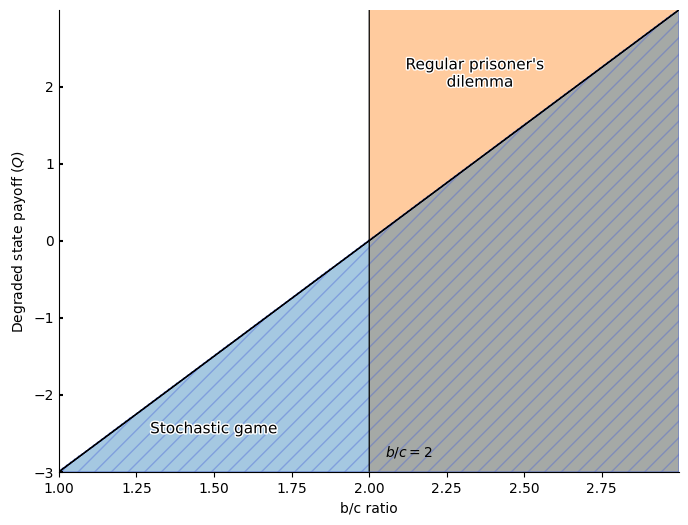

In [10]:
from matplotlib.patches import Patch
import matplotlib.patheffects as pe

X, Y = np.meshgrid(B, Q)
delta = 0.5
# Define two functions (e.g., inequalities)
regular = grim_check(X,Y)
stochastic = grim_check(X,Y,1)

# Creating the plot
plt.figure(figsize=(8, 6))

# Shade the regions
ccf = plt.contourf(X, Y, regular, levels=[0.1, 1.1], colors=['#ff7f0e'], alpha=0.4)
cf = plt.contourf(X, Y, stochastic, levels=[0.1, 1.1], colors=['#1f77b4'], alpha=0.4)
for c in cf.collections:
    c.set_hatch('//')  
    c.set_edgecolor('#4a63d8')  
    c.set_linewidth(0.8)


plt.contour(X, Y, regular, levels=[0.5], colors='black', linestyles='solid',linewidths=0.9)
plt.contour(X, Y, stochastic, levels=[0.5], colors='black', linestyles='solid',linewidths=0.9)


plt.text(1.5, -2.5,
         "Stochastic game",
         fontsize=11,
         ha='center',
         path_effects=[pe.withStroke(linewidth=2, foreground="white")],color='black')

plt.text(2.35, 2.,
         "Regular prisoner's \n dilemma",
         fontsize=11,
         ha='center',
         path_effects=[pe.withStroke(linewidth=2, foreground="white")],color='black')
plt.annotate(r"$b/c = 2$",
             xy=(2, -2.8),
             xytext=(2.05, -2.8),
             fontsize=10)


ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('b/c ratio')
plt.ylabel(r"Degraded state payoff ($Q$)")
plt.grid(False)
plt.tick_params(axis='y', direction='in', length=3, width=1.5)
plt.savefig("GRIM.png", dpi=300)  
plt.show()